# SMS-Aware Feature Engineering

## Objective

Day 7 error analysis revealed several recurring patterns in false-negative
spam messages:

- Phone numbers
- Prices and monetary values
- Short messages
- SMS-style abbreviations
- Numeric-heavy messages
- Promotional language
- Obfuscated wording

This experiment investigates whether explicit SMS-specific features can
improve the Logistic Regression baseline.

The baseline model uses unigram TF-IDF features.

The experiment will add handcrafted numeric features and compare the
result against the existing baseline.

## Experiment Principle

We will change one major component at a time and keep the train/test
split consistent with the previous experiments.

This allows us to determine whether the new features actually contribute
to model performance.

In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from scipy.sparse import hstack

In [2]:
df = pd.read_csv(
    "../data/spam.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = pd.read_csv(
    "../data/spam.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# Inspect the columns first
print(df.columns.tolist())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [5]:
df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

df = df[["label", "message"]].copy()

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
print(df.columns.tolist())
print(df.shape)

['label', 'message']
(5572, 2)


In [7]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df["label"].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [8]:
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 4457
Test samples: 1115


## Baseline Reproduction

Before introducing SMS-specific features, we reproduce the existing
unigram TF-IDF + Logistic Regression baseline.

This gives us a control result for the experiment.

In [9]:
baseline_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1)
)

X_train_tfidf = baseline_vectorizer.fit_transform(X_train)
X_test_tfidf = baseline_vectorizer.transform(X_test)

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

baseline_pred = baseline_model.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline Logistic Regression")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

Baseline Logistic Regression
Accuracy : 0.9722
Precision: 0.9917
Recall   : 0.7987
F1-Score : 0.8848


## Feature 1 — Message Length

Some spam messages are long promotional messages, while others are
extremely short messages containing only a keyword, shortcode, or phone
number.

We will create a message-length feature and inspect whether message
length differs between ham and spam.

The feature will be calculated from the original message text.

In [10]:
df["message_length"] = df["message"].str.len()

df[["label", "message", "message_length"]].head(10)

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
5,1,FreeMsg Hey there darling it's been 3 week's n...,148
6,0,Even my brother is not like to speak with me. ...,77
7,0,As per your request 'Melle Melle (Oru Minnamin...,160
8,1,WINNER!! As a valued network customer you have...,158
9,1,Had your mobile 11 months or more? U R entitle...,154


In [11]:
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
1,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


## Message Length Distribution

We visualize message length by class to determine whether this feature
contains useful information for distinguishing spam from ham.

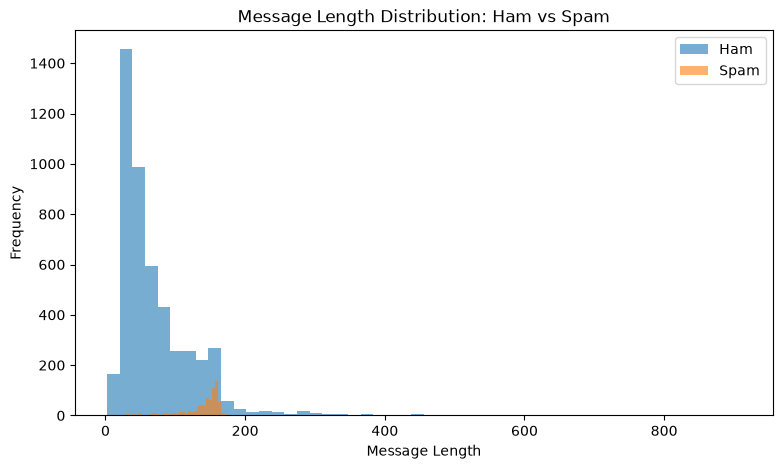

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    df[df["label"] == 0]["message_length"],
    bins=50,
    alpha=0.6,
    label="Ham"
)

plt.hist(
    df[df["label"] == 1]["message_length"],
    bins=50,
    alpha=0.6,
    label="Spam"
)

plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Message Length Distribution: Ham vs Spam")
plt.legend()

plt.show()

In [13]:
df.sort_values("message_length")[[
    "label",
    "message",
    "message_length"
]].head(20)

,label,message,message_length
5357,0,Ok,2
1924,0,Ok,2
4496,0,Ok,2
3049,0,Ok,2
5268,0,\ER,3
3831,0,Ok.,3
4012,0,Ok.,3
2181,0,Ok.,3
5471,0,Yup,3
3490,0,Ok.,3


In [14]:
df.sort_values(
    "message_length",
    ascending=False
)[[
    "label",
    "message",
    "message_length"
]].head(20)

,label,message,message_length
1084,0,For me the love should start with attraction.i...,910
1862,0,The last thing i ever wanted to do was hurt yo...,790
2433,0,Indians r poor but India is not a poor country...,632
1578,0,How to Make a girl Happy? It's not at all diff...,611
2847,0,Sad story of a Man - Last week was my b'day. M...,588
2157,0,Sad story of a Man - Last week was my b'day. M...,588
2379,0,"Good evening Sir, hope you are having a nice d...",482
3015,0,"&lt;#&gt; is fast approaching. So, Wish u a v...",461
1512,0,"Hey sweet, I was wondering when you had a mome...",458
5104,0,A Boy loved a gal. He propsd bt she didnt mind...,450


In [15]:
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
1,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


## Adding Message Length to the Model

Message length is a numerical feature, while TF-IDF produces sparse
text features.

We will calculate the length feature separately for the training and
test sets and then combine it with the TF-IDF representation.

In [16]:
X_train_length = X_train.str.len().values.reshape(-1, 1)
X_test_length = X_test.str.len().values.reshape(-1, 1)

print("Training length shape:", X_train_length.shape)
print("Test length shape:", X_test_length.shape)

Training length shape: (4457, 1)
Test length shape: (1115, 1)


In [17]:
from sklearn.preprocessing import StandardScaler

length_scaler = StandardScaler()

X_train_length_scaled = length_scaler.fit_transform(X_train_length)
X_test_length_scaled = length_scaler.transform(X_test_length)

In [18]:
X_train_combined = hstack([
    X_train_tfidf,
    X_train_length_scaled
])

X_test_combined = hstack([
    X_test_tfidf,
    X_test_length_scaled
])

print("TF-IDF shape:", X_train_tfidf.shape)
print("Combined shape:", X_train_combined.shape)

TF-IDF shape: (4457, 7701)
Combined shape: (4457, 7702)


In [19]:
length_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

length_model.fit(
    X_train_combined,
    y_train
)

length_pred = length_model.predict(X_test_combined)

In [20]:
length_accuracy = accuracy_score(y_test, length_pred)
length_precision = precision_score(y_test, length_pred)
length_recall = recall_score(y_test, length_pred)
length_f1 = f1_score(y_test, length_pred)

print("TF-IDF + Message Length")
print(f"Accuracy : {length_accuracy:.4f}")
print(f"Precision: {length_precision:.4f}")
print(f"Recall   : {length_recall:.4f}")
print(f"F1-Score : {length_f1:.4f}")

TF-IDF + Message Length
Accuracy : 0.9722
Precision: 0.9609
Recall   : 0.8255
F1-Score : 0.8881


In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF",
        "TF-IDF + Message Length"
    ],
    "Accuracy": [
        baseline_accuracy,
        length_accuracy
    ],
    "Precision": [
        baseline_precision,
        length_precision
    ],
    "Recall": [
        baseline_recall,
        length_recall
    ],
    "F1-Score": [
        baseline_f1,
        length_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline TF-IDF,0.972197,0.991667,0.798658,0.884758
1,TF-IDF + Message Length,0.972197,0.960938,0.825503,0.888087


## Error Analysis — TF-IDF + Message Length

The baseline model missed spam messages that appeared in several
SMS-specific patterns.

We will compare the false negatives produced by the baseline against
the false negatives produced after adding message length.

The goal is to determine whether the new feature addresses the failure
mode identified during Day 7.

In [22]:
baseline_false_negative_mask = (
    (y_test == 1) &
    (baseline_pred == 0)
)

length_false_negative_mask = (
    (y_test == 1) &
    (length_pred == 0)
)

baseline_fn_count = baseline_false_negative_mask.sum()
length_fn_count = length_false_negative_mask.sum()

print("Baseline false negatives:", baseline_fn_count)
print("TF-IDF + Message Length false negatives:", length_fn_count)

Baseline false negatives: 30
TF-IDF + Message Length false negatives: 26


In [23]:
print("Baseline false negatives:")
print(
    X_test[baseline_false_negative_mask]
    .head(10)
    .to_string(index=False)
)

print("\nTF-IDF + Message Length false negatives:")
print(
    X_test[length_false_negative_mask]
    .head(10)
    .to_string(index=False)
)

Baseline false negatives:
FreeMsg Hey there darling it's been 3 week's no...
Dear Voucher Holder 2 claim your 1st class airp...
Talk sexy!! Make new friends or fall in love in...
Hi if ur lookin 4 saucy daytime fun wiv busty m...
                                ringtoneking 84484
Sorry I missed your call let's talk when you ha...
Rock yr chik. Get 100's of filthy films &XXX pi...
Latest News! Police station toilet stolen, cops...
Sunshine Quiz! Win a super Sony DVD recorder if...
TheMob>Hit the link to get a premium Pink Panth...

TF-IDF + Message Length false negatives:
FreeMsg Hey there darling it's been 3 week's no...
Dear Voucher Holder 2 claim your 1st class airp...
Hi if ur lookin 4 saucy daytime fun wiv busty m...
it to 80488. Your 500 free text messages are va...
                                ringtoneking 84484
Sorry I missed your call let's talk when you ha...
Latest News! Police station toilet stolen, cops...
Sunshine Quiz! Win a super Sony DVD recorder if...
Bloomberg -Mes

## Message Length Experiment — Decision

Message length was evaluated as an additional numerical feature.

The feature should only be retained if it provides meaningful
improvement over the baseline in the metrics or addresses a meaningful
failure mode.

We compare:

- Accuracy
- Precision
- Recall
- F1-score
- Number of false negatives

This experiment will determine whether message length should remain in
the feature set for subsequent experiments.

In [24]:
print("Baseline F1:", round(baseline_f1, 4))
print("Length F1:", round(length_f1, 4))

print("\nBaseline false negatives:", baseline_fn_count)
print("Length false negatives:", length_fn_count)

if length_f1 > baseline_f1:
    print("\nDecision: Message length improves F1 and will be retained.")
elif length_fn_count < baseline_fn_count:
    print("\nDecision: Message length reduces false negatives and may be retained.")
else:
    print("\nDecision: Message length does not provide a meaningful improvement.")

Baseline F1: 0.8848
Length F1: 0.8881

Baseline false negatives: 30
Length false negatives: 26

Decision: Message length improves F1 and will be retained.


## Feature 2 — Numeric Character Count

Many spam messages in the error analysis contained phone numbers,
premium-rate numbers, prices, and shortcodes.

We create a numerical feature representing the number of numeric
characters present in each message.

This is intentionally simple. The goal is to determine whether explicit
numeric information provides useful signal beyond TF-IDF.

In [25]:
df["digit_count"] = df["message"].str.count(r"\d")

df[[
    "label",
    "message",
    "digit_count"
]].head(10)

,label,message,digit_count
0,0,"Go until jurong point, crazy.. Available only ...",0
1,0,Ok lar... Joking wif u oni...,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,25
3,0,U dun say so early hor... U c already then say...,0
4,0,"Nah I don't think he goes to usf, he lives aro...",0
5,1,FreeMsg Hey there darling it's been 3 week's n...,4
6,0,Even my brother is not like to speak with me. ...,0
7,0,As per your request 'Melle Melle (Oru Minnamin...,1
8,1,WINNER!! As a valued network customer you have...,19
9,1,Had your mobile 11 months or more? U R entitle...,13


In [26]:
df.groupby("label")["digit_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4825.0,0.299275,1.063086,0.0,0.0,0.0,0.0,23.0
1,747.0,15.759036,8.755896,0.0,10.0,16.0,22.0,47.0


In [27]:
df.sort_values(
    "digit_count",
    ascending=False
)[[
    "label",
    "message",
    "digit_count"
]].head(20)

,label,message,digit_count
716,1,+449071512431 URGENT! This is the 2nd attempt ...,47
504,1,+123 Congratulations - in this week's competit...,41
2123,1,+123 Congratulations - in this week's competit...,41
530,1,PRIVATE! Your 2003 Account Statement for 07815...,40
592,1,PRIVATE! Your 2003 Account Statement for 07753...,40
5501,1,PRIVATE! Your 2003 Account Statement for 07808...,40
4086,1,PRIVATE! Your 2003 Account Statement for 07973...,40
3162,1,This is the 2nd time we have tried to contact ...,37
4806,1,PRIVATE! Your 2004 Account Statement for 07849...,36
1462,1,09066362231 URGENT! Your mobile No 07xxxxxxxxx...,35


## Adding Numeric Features to the Model

The digit-count feature will be calculated separately for the training
and test sets.

The training data will be used to fit the scaler, while the test data
will only be transformed.

In [28]:
X_train_digit_count = X_train.str.count(r"\d").values.reshape(-1, 1)
X_test_digit_count = X_test.str.count(r"\d").values.reshape(-1, 1)

print("Training digit feature shape:", X_train_digit_count.shape)
print("Test digit feature shape:", X_test_digit_count.shape)

Training digit feature shape: (4457, 1)
Test digit feature shape: (1115, 1)


In [29]:
digit_scaler = StandardScaler()

X_train_digit_scaled = digit_scaler.fit_transform(
    X_train_digit_count
)

X_test_digit_scaled = digit_scaler.transform(
    X_test_digit_count
)

In [30]:
X_train_digit_combined = hstack([
    X_train_tfidf,
    X_train_digit_scaled
])

X_test_digit_combined = hstack([
    X_test_tfidf,
    X_test_digit_scaled
])

print("Baseline TF-IDF shape:", X_train_tfidf.shape)
print("Digit-enhanced shape:", X_train_digit_combined.shape)

Baseline TF-IDF shape: (4457, 7701)
Digit-enhanced shape: (4457, 7702)


In [31]:
digit_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

digit_model.fit(
    X_train_digit_combined,
    y_train
)

digit_pred = digit_model.predict(
    X_test_digit_combined
)

In [32]:
digit_accuracy = accuracy_score(
    y_test,
    digit_pred
)

digit_precision = precision_score(
    y_test,
    digit_pred
)

digit_recall = recall_score(
    y_test,
    digit_pred
)

digit_f1 = f1_score(
    y_test,
    digit_pred
)

print("TF-IDF + Digit Count")
print(f"Accuracy : {digit_accuracy:.4f}")
print(f"Precision: {digit_precision:.4f}")
print(f"Recall   : {digit_recall:.4f}")
print(f"F1-Score : {digit_f1:.4f}")

TF-IDF + Digit Count
Accuracy : 0.9758
Precision: 0.9552
Recall   : 0.8591
F1-Score : 0.9046


In [33]:
digit_comparison = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF",
        "TF-IDF + Digit Count"
    ],
    "Accuracy": [
        baseline_accuracy,
        digit_accuracy
    ],
    "Precision": [
        baseline_precision,
        digit_precision
    ],
    "Recall": [
        baseline_recall,
        digit_recall
    ],
    "F1-Score": [
        baseline_f1,
        digit_f1
    ]
})

digit_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline TF-IDF,0.972197,0.991667,0.798658,0.884758
1,TF-IDF + Digit Count,0.975785,0.955224,0.859060,0.904594


## Error Analysis — Digit Count

The digit-count feature improved recall substantially.

We will now compare false negatives from the baseline against the
digit-enhanced model.

The objective is to determine whether the improvement corresponds to
the SMS-specific failure modes identified during Day 7.

In [34]:
baseline_fn_mask = (
    (y_test == 1) &
    (baseline_pred == 0)
)

digit_fn_mask = (
    (y_test == 1) &
    (digit_pred == 0)
)

baseline_fn_count = baseline_fn_mask.sum()
digit_fn_count = digit_fn_mask.sum()

print("Baseline false negatives:", baseline_fn_count)
print("Digit Count false negatives:", digit_fn_count)

Baseline false negatives: 30
Digit Count false negatives: 21


In [35]:
recovered_spam_mask = (
    (y_test == 1) &
    (baseline_pred == 0) &
    (digit_pred == 1)
)

recovered_spam = X_test[recovered_spam_mask]

print("Spam messages recovered by digit count:")
print("Count:", len(recovered_spam))

for message in recovered_spam.head(20):
    print("\n---")
    print(message)

Spam messages recovered by digit count:
Count: 17

---
Dear Voucher Holder 2 claim your 1st class airport lounge passes when using Your holiday voucher call 08704439680. When booking quote 1st class x 2

---
Talk sexy!! Make new friends or fall in love in the worlds most discreet text dating service. Just text VIP to 83110 and see who you could meet.

---
Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Callså£1/minMobsmoreLKPOBOX177HP51FL

---
Sorry I missed your call let's talk when you have the time. I'm on 07090201529

---
Rock yr chik. Get 100's of filthy films &XXX pics on yr phone now. rply FILTH to 69669. Saristar Ltd, E14 9YT 08701752560. 450p per 5 days. Stop2 cancel

---
Sunshine Quiz! Win a super Sony DVD recorder if you canname the capital of Australia? Text MQUIZ to 82277. B

---
Bloomberg -Message center +447797706009 Why wait? Apply for your future http://careers. bloomberg.com

---
Romantic Pari

## Digit Count Experiment — Decision

Adding digit count improved recall and F1-score compared with the
baseline.

The model catches more spam messages, but precision decreases slightly.

This is a useful result because false negatives were identified as the
primary weakness during the previous error analysis.

The digit-count feature will therefore be retained as a candidate
feature for the next combined experiment.

However, we will not yet consider it a final feature until it is tested
alongside the other engineered features.

In [36]:
print("Baseline")
print(f"  Precision: {baseline_precision:.4f}")
print(f"  Recall:    {baseline_recall:.4f}")
print(f"  F1:        {baseline_f1:.4f}")
print(f"  FN:        {baseline_fn_count}")

print("\nTF-IDF + Digit Count")
print(f"  Precision: {digit_precision:.4f}")
print(f"  Recall:    {digit_recall:.4f}")
print(f"  F1:        {digit_f1:.4f}")
print(f"  FN:        {digit_fn_count}")

Baseline
  Precision: 0.9917
  Recall:    0.7987
  F1:        0.8848
  FN:        30

TF-IDF + Digit Count
  Precision: 0.9552
  Recall:    0.8591
  F1:        0.9046
  FN:        21


## Feature 3 — Phone Number Presence

Several false-negative spam messages contained phone numbers,
premium-rate numbers, and service numbers.

A binary feature is introduced to indicate whether a message contains
a phone-number-like pattern.

This tests whether explicit phone-number information provides useful
signal beyond the digit-count feature.

In [37]:
import re

def has_phone_number(text):
    pattern = r"(?<!\d)(?:\+?\d[\d\s\-]{6,}\d)(?!\d)"
    return int(bool(re.search(pattern, text)))

df["has_phone_number"] = df["message"].apply(has_phone_number)

df[[
    "label",
    "message",
    "has_phone_number"
]].head(20)

,label,message,has_phone_number
0,0,"Go until jurong point, crazy.. Available only ...",0
1,0,Ok lar... Joking wif u oni...,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,0,U dun say so early hor... U c already then say...,0
4,0,"Nah I don't think he goes to usf, he lives aro...",0
5,1,FreeMsg Hey there darling it's been 3 week's n...,0
6,0,Even my brother is not like to speak with me. ...,0
7,0,As per your request 'Melle Melle (Oru Minnamin...,0
8,1,WINNER!! As a valued network customer you have...,1
9,1,Had your mobile 11 months or more? U R entitle...,1


In [38]:
df.groupby("label")["has_phone_number"].mean()

label
0    0.000829
1    0.593039
Name: has_phone_number, dtype: float64

In [39]:
pd.crosstab(
    df["label"],
    df["has_phone_number"],
    normalize="index"
)

has_phone_number,0,1
label,,
0,0.999171,0.000829
1,0.406961,0.593039


In [40]:
phone_examples = df[df["has_phone_number"] == 1][[
    "label",
    "message"
]]

phone_examples.head(20)

,label,message
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...
42,1,07732584351 - Rodger Burns - MSG = We tried to...
56,1,Congrats! 1 year special cinema pass for 2 is ...
65,1,"As a valued customer, I am pleased to advise y..."
67,1,Urgent UR awarded a complimentary trip to Euro...
93,1,Please call our customer service representativ...
113,1,GENT! We are trying to contact you. Last weeke...
116,1,You are a winner U have been specially selecte...


In [41]:
print("Messages detected as containing phone numbers:",
      len(phone_examples))

Messages detected as containing phone numbers: 447


## Adding Phone Number Presence to the Model

The phone-number feature is generated separately for the training and
test sets.

The feature will be combined with the baseline TF-IDF representation.

In [42]:
X_train_phone = (
    X_train
    .apply(has_phone_number)
    .values
    .reshape(-1, 1)
)

X_test_phone = (
    X_test
    .apply(has_phone_number)
    .values
    .reshape(-1, 1)
)

print("Training phone feature shape:", X_train_phone.shape)
print("Test phone feature shape:", X_test_phone.shape)

Training phone feature shape: (4457, 1)
Test phone feature shape: (1115, 1)


In [43]:
X_train_phone_combined = hstack([
    X_train_tfidf,
    X_train_phone
])

X_test_phone_combined = hstack([
    X_test_tfidf,
    X_test_phone
])

print("Baseline shape:", X_train_tfidf.shape)
print("Phone-enhanced shape:", X_train_phone_combined.shape)

Baseline shape: (4457, 7701)
Phone-enhanced shape: (4457, 7702)


In [44]:
phone_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

phone_model.fit(
    X_train_phone_combined,
    y_train
)

phone_pred = phone_model.predict(
    X_test_phone_combined
)

In [45]:
phone_accuracy = accuracy_score(
    y_test,
    phone_pred
)

phone_precision = precision_score(
    y_test,
    phone_pred
)

phone_recall = recall_score(
    y_test,
    phone_pred
)

phone_f1 = f1_score(
    y_test,
    phone_pred
)

print("TF-IDF + Phone Number")
print(f"Accuracy : {phone_accuracy:.4f}")
print(f"Precision: {phone_precision:.4f}")
print(f"Recall   : {phone_recall:.4f}")
print(f"F1-Score : {phone_f1:.4f}")

TF-IDF + Phone Number
Accuracy : 0.9713
Precision: 0.9756
Recall   : 0.8054
F1-Score : 0.8824


In [46]:
feature_comparison = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF",
        "TF-IDF + Digit Count",
        "TF-IDF + Phone Number"
    ],
    "Accuracy": [
        baseline_accuracy,
        digit_accuracy,
        phone_accuracy
    ],
    "Precision": [
        baseline_precision,
        digit_precision,
        phone_precision
    ],
    "Recall": [
        baseline_recall,
        digit_recall,
        phone_recall
    ],
    "F1-Score": [
        baseline_f1,
        digit_f1,
        phone_f1
    ]
})

feature_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline TF-IDF,0.972197,0.991667,0.798658,0.884758
1,TF-IDF + Digit Count,0.975785,0.955224,0.859060,0.904594
2,TF-IDF + Phone Number,0.971300,0.975610,0.805369,0.882353


In [47]:
phone_fn_mask = (
    (y_test == 1) &
    (phone_pred == 0)
)

phone_fn_count = phone_fn_mask.sum()

print("Baseline false negatives:", baseline_fn_count)
print("Digit Count false negatives:", digit_fn_count)
print("Phone Number false negatives:", phone_fn_count)

Baseline false negatives: 30
Digit Count false negatives: 21
Phone Number false negatives: 29


In [48]:
phone_recovered_mask = (
    (y_test == 1) &
    (baseline_pred == 0) &
    (phone_pred == 1)
)

phone_recovered = X_test[phone_recovered_mask]

print("Spam recovered by phone-number feature:")
print("Count:", len(phone_recovered))

for message in phone_recovered.head(20):
    print("\n---")
    print(message)

Spam recovered by phone-number feature:
Count: 11

---
Dear Voucher Holder 2 claim your 1st class airport lounge passes when using Your holiday voucher call 08704439680. When booking quote 1st class x 2

---
Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Callså£1/minMobsmoreLKPOBOX177HP51FL

---
Sorry I missed your call let's talk when you have the time. I'm on 07090201529

---
Rock yr chik. Get 100's of filthy films &XXX pics on yr phone now. rply FILTH to 69669. Saristar Ltd, E14 9YT 08701752560. 450p per 5 days. Stop2 cancel

---
Bloomberg -Message center +447797706009 Why wait? Apply for your future http://careers. bloomberg.com

---
Romantic Paris. 2 nights, 2 flights from å£79 Book now 4 next year. Call 08704439680Ts&Cs apply.

---
Can U get 2 phone NOW? I wanna chat 2 set up meet Call me NOW on 09096102316 U can cum here 2moro Luv JANE xx Callså£1/minmoremobsEMSPOBox45PO139WA

---
You have 1 new voicema

## Feature Combination — Digit Count + Phone Number

Digit count and phone-number presence both improved the baseline
individually.

We now combine both features to determine whether they provide
complementary information.

The combined representation contains:

- TF-IDF features
- Digit count
- Phone-number presence

In [49]:
X_train_numeric_combined = hstack([
    X_train_tfidf,
    X_train_digit_scaled,
    X_train_phone
])

X_test_numeric_combined = hstack([
    X_test_tfidf,
    X_test_digit_scaled,
    X_test_phone
])

print("Baseline features:", X_train_tfidf.shape)
print("Combined features:", X_train_numeric_combined.shape)

Baseline features: (4457, 7701)
Combined features: (4457, 7703)


In [50]:
numeric_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

numeric_model.fit(
    X_train_numeric_combined,
    y_train
)

numeric_pred = numeric_model.predict(
    X_test_numeric_combined
)

In [51]:
numeric_accuracy = accuracy_score(
    y_test,
    numeric_pred
)

numeric_precision = precision_score(
    y_test,
    numeric_pred
)

numeric_recall = recall_score(
    y_test,
    numeric_pred
)

numeric_f1 = f1_score(
    y_test,
    numeric_pred
)

print("TF-IDF + Digit Count + Phone Number")
print(f"Accuracy : {numeric_accuracy:.4f}")
print(f"Precision: {numeric_precision:.4f}")
print(f"Recall   : {numeric_recall:.4f}")
print(f"F1-Score : {numeric_f1:.4f}")

TF-IDF + Digit Count + Phone Number
Accuracy : 0.9740
Precision: 0.9478
Recall   : 0.8523
F1-Score : 0.8975


In [52]:
all_feature_comparison = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF",
        "TF-IDF + Digit Count",
        "TF-IDF + Phone Number",
        "TF-IDF + Digit Count + Phone Number"
    ],
    "Accuracy": [
        baseline_accuracy,
        digit_accuracy,
        phone_accuracy,
        numeric_accuracy
    ],
    "Precision": [
        baseline_precision,
        digit_precision,
        phone_precision,
        numeric_precision
    ],
    "Recall": [
        baseline_recall,
        digit_recall,
        phone_recall,
        numeric_recall
    ],
    "F1-Score": [
        baseline_f1,
        digit_f1,
        phone_f1,
        numeric_f1
    ]
})

all_feature_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline TF-IDF,0.972197,0.991667,0.798658,0.884758
1,TF-IDF + Digit Count,0.975785,0.955224,0.859060,0.904594
2,TF-IDF + Phone Number,0.971300,0.975610,0.805369,0.882353
3,TF-IDF + Digit Count + Phone Number,0.973991,0.947761,0.852349,0.897527


In [53]:
numeric_fn_mask = (
    (y_test == 1) &
    (numeric_pred == 0)
)

numeric_fn_count = numeric_fn_mask.sum()

print("False Negative Comparison")
print("-------------------------")
print("Baseline TF-IDF:", baseline_fn_count)
print("Digit Count:", digit_fn_count)
print("Phone Number:", phone_fn_count)
print("Digit + Phone:", numeric_fn_count)

False Negative Comparison
-------------------------
Baseline TF-IDF: 30
Digit Count: 21
Phone Number: 29
Digit + Phone: 22


## Numeric Feature Experiment — Decision

Three representations were evaluated:

1. Baseline TF-IDF
2. TF-IDF + Digit Count
3. TF-IDF + Phone Number
4. TF-IDF + Digit Count + Phone Number

The final choice will be based primarily on F1-score and recall,
while considering the precision trade-off.

The selected representation should improve spam detection without
introducing an unacceptable number of false positives.

In [54]:
best_row = all_feature_comparison.loc[
    all_feature_comparison["F1-Score"].idxmax()
]

print("Best representation:")
print(best_row)

Best representation:
Model        TF-IDF + Digit Count
Accuracy                 0.975785
Precision                0.955224
Recall                    0.85906
F1-Score                 0.904594
Name: 1, dtype: object


## Feature 4 — Spam Keyword Signals

The error analysis revealed recurring vocabulary associated with
promotional, premium-rate, and unsolicited messages.

We create a numerical feature representing the number of
spam-associated keywords appearing in each message.

This tests whether explicit domain knowledge provides additional
signal beyond TF-IDF and numeric features.

In [55]:
spam_keywords = [
    "free",
    "win",
    "winner",
    "prize",
    "claim",
    "urgent",
    "call",
    "txt",
    "text",
    "reply",
    "offer",
    "cash",
    "voucher",
    "bonus",
    "stop"
]

def spam_keyword_count(text):
    text = text.lower()
    
    return sum(
        len(re.findall(r"\b" + re.escape(word) + r"\b", text))
        for word in spam_keywords
    )

df["spam_keyword_count"] = df["message"].apply(spam_keyword_count)

df[[
    "label",
    "message",
    "spam_keyword_count"
]].head(20)

,label,message,spam_keyword_count
0,0,"Go until jurong point, crazy.. Available only ...",0
1,0,Ok lar... Joking wif u oni...,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,4
3,0,U dun say so early hor... U c already then say...,0
4,0,"Nah I don't think he goes to usf, he lives aro...",0
5,1,FreeMsg Hey there darling it's been 3 week's n...,0
6,0,Even my brother is not like to speak with me. ...,0
7,0,As per your request 'Melle Melle (Oru Minnamin...,0
8,1,WINNER!! As a valued network customer you have...,5
9,1,Had your mobile 11 months or more? U R entitle...,3


In [56]:
df.groupby("label")["spam_keyword_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4825.0,0.103005,0.343685,0.0,0.0,0.0,0.0,3.0
1,747.0,2.116466,1.414625,0.0,1.0,2.0,3.0,7.0


In [57]:
pd.crosstab(
    df["label"],
    df["spam_keyword_count"],
    normalize="index"
)

spam_keyword_count,0,1,2,3,4,5,6,7
label,,,,,,,,
0,0.909016,0.079793,0.010363,0.000829,0.000000,0.000000,0.000000,0.000000
1,0.123159,0.257028,0.236948,0.210174,0.125837,0.032129,0.012048,0.002677


In [58]:
df.sort_values(
    "spam_keyword_count",
    ascending=False
)[[
    "label",
    "message",
    "spam_keyword_count"
]].head(20)

,label,message,spam_keyword_count
5190,1,Our records indicate u maybe entitled to 5000 ...,7
2692,1,Urgent Urgent! We have 800 FREE flights to Eur...,7
634,1,"Dear Voucher Holder, 2 claim this weeks offer,...",6
4089,1,We tried to call you re your reply to our sms ...,6
4384,1,Do you want a New Nokia 3510i Colour Phone Del...,6
3012,1,FREE UNLIMITED HARDCORE PORN direct 2 your mob...,6
3421,1,Freemsg: 1-month unlimited free calls! Activat...,6
3593,1,Do you want a New Nokia 3510i Colour Phone Del...,6
3997,1,We tried to call you re your reply to our sms ...,6
400,1,FREE RINGTONE text FIRST to 87131 for a poly o...,6


In [59]:
X_train_keyword = (
    X_train
    .apply(spam_keyword_count)
    .values
    .reshape(-1, 1)
)

X_test_keyword = (
    X_test
    .apply(spam_keyword_count)
    .values
    .reshape(-1, 1)
)

print("Training keyword feature:", X_train_keyword.shape)
print("Test keyword feature:", X_test_keyword.shape)

Training keyword feature: (4457, 1)
Test keyword feature: (1115, 1)


In [60]:
keyword_scaler = StandardScaler()

X_train_keyword_scaled = keyword_scaler.fit_transform(
    X_train_keyword
)

X_test_keyword_scaled = keyword_scaler.transform(
    X_test_keyword
)

In [61]:
X_train_keyword_combined = hstack([
    X_train_tfidf,
    X_train_keyword_scaled
])

X_test_keyword_combined = hstack([
    X_test_tfidf,
    X_test_keyword_scaled
])

In [62]:
keyword_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

keyword_model.fit(
    X_train_keyword_combined,
    y_train
)

keyword_pred = keyword_model.predict(
    X_test_keyword_combined
)

In [63]:
keyword_accuracy = accuracy_score(
    y_test,
    keyword_pred
)

keyword_precision = precision_score(
    y_test,
    keyword_pred
)

keyword_recall = recall_score(
    y_test,
    keyword_pred
)

keyword_f1 = f1_score(
    y_test,
    keyword_pred
)

print("TF-IDF + Spam Keyword Count")
print(f"Accuracy : {keyword_accuracy:.4f}")
print(f"Precision: {keyword_precision:.4f}")
print(f"Recall   : {keyword_recall:.4f}")
print(f"F1-Score : {keyword_f1:.4f}")

TF-IDF + Spam Keyword Count
Accuracy : 0.9632
Precision: 0.9286
Recall   : 0.7852
F1-Score : 0.8509


In [64]:
final_feature_comparison = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF",
        "TF-IDF + Digit Count",
        "TF-IDF + Phone Number",
        "TF-IDF + Digit + Phone",
        "TF-IDF + Keyword Count"
    ],
    "Accuracy": [
        baseline_accuracy,
        digit_accuracy,
        phone_accuracy,
        numeric_accuracy,
        keyword_accuracy
    ],
    "Precision": [
        baseline_precision,
        digit_precision,
        phone_precision,
        numeric_precision,
        keyword_precision
    ],
    "Recall": [
        baseline_recall,
        digit_recall,
        phone_recall,
        numeric_recall,
        keyword_recall
    ],
    "F1-Score": [
        baseline_f1,
        digit_f1,
        phone_f1,
        numeric_f1,
        keyword_f1
    ]
})

final_feature_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline TF-IDF,0.972197,0.991667,0.798658,0.884758
1,TF-IDF + Digit Count,0.975785,0.955224,0.859060,0.904594
2,TF-IDF + Phone Number,0.971300,0.975610,0.805369,0.882353
3,TF-IDF + Digit + Phone,0.973991,0.947761,0.852349,0.897527
4,TF-IDF + Keyword Count,0.963229,0.928571,0.785235,0.850909


In [65]:
keyword_fn_mask = (
    (y_test == 1) &
    (keyword_pred == 0)
)

keyword_fn_count = keyword_fn_mask.sum()

print("False Negative Comparison")
print("-------------------------")
print("Baseline TF-IDF:", baseline_fn_count)
print("Digit Count:", digit_fn_count)
print("Phone Number:", phone_fn_count)
print("Digit + Phone:", numeric_fn_count)
print("Keyword Count:", keyword_fn_count)

False Negative Comparison
-------------------------
Baseline TF-IDF: 30
Digit Count: 21
Phone Number: 29
Digit + Phone: 22
Keyword Count: 32


## Feature Engineering — Final Selection

Several feature-engineering strategies were evaluated against the
baseline unigram TF-IDF representation.

The experiments showed:

- Digit Count significantly improved recall and F1-score.
- Phone Number Presence provided limited independent improvement.
- Combining Phone Number with Digit Count did not outperform Digit Count.
- Manually defined Spam Keyword Count reduced overall performance.

Therefore, TF-IDF + Digit Count is selected as the best engineered
representation based on F1-score, recall, and false-negative reduction.

This representation will be carried forward as the candidate feature
set for the final model.

In [66]:
import joblib
import json

In [67]:
joblib.dump(
    digit_scaler,
    "../models/digit_count_scaler.pkl"
)

['../models/digit_count_scaler.pkl']

In [68]:
feature_config = {
    "text_features": "TF-IDF unigram",
    "numeric_features": [
        "digit_count"
    ],
    "model": "LogisticRegression",
    "selection_reason": (
        "Highest F1-score with improved recall and reduced "
        "false negatives compared with baseline."
    )
}

with open(
    "../models/feature_config.json",
    "w"
) as f:
    json.dump(
        feature_config,
        f,
        indent=4
    )

In [69]:
joblib.dump(
    digit_model,
    "../models/digit_count_logistic_regression_model.pkl"
)

['../models/digit_count_logistic_regression_model.pkl']

In [70]:
[name for name in globals() if "vector" in name.lower()]

['TfidfVectorizer', 'baseline_vectorizer']

In [71]:
[name for name, value in globals().items()
 if type(value).__name__ == "TfidfVectorizer"]

['baseline_vectorizer']

In [72]:
joblib.dump(
    baseline_vectorizer,
    "../models/digit_count_tfidf_vectorizer.pkl"
)

['../models/digit_count_tfidf_vectorizer.pkl']

In [73]:
import os

artifacts = [
    "../models/digit_count_tfidf_vectorizer.pkl",
    "../models/digit_count_scaler.pkl",
    "../models/digit_count_logistic_regression_model.pkl"
]

for artifact in artifacts:
    print(artifact, "->", os.path.exists(artifact))

../models/digit_count_tfidf_vectorizer.pkl -> True
../models/digit_count_scaler.pkl -> True
../models/digit_count_logistic_regression_model.pkl -> True


In [74]:
from pathlib import Path

model_dir = Path("../models")

artifacts = [
    "digit_count_tfidf_vectorizer.pkl",
    "digit_count_scaler.pkl",
    "digit_count_logistic_regression_model.pkl",
    "feature_config.json",
]

for artifact in artifacts:
    path = model_dir / artifact
    print(f"{artifact}: {path.exists()}")

digit_count_tfidf_vectorizer.pkl: True
digit_count_scaler.pkl: True
digit_count_logistic_regression_model.pkl: True
feature_config.json: True


In [75]:
import json

config_path = model_dir / "feature_config.json"

with open(config_path, "r") as f:
    feature_config = json.load(f)

feature_config

{'text_features': 'TF-IDF unigram',
 'numeric_features': ['digit_count'],
 'model': 'LogisticRegression',
 'selection_reason': 'Highest F1-score with improved recall and reduced false negatives compared with baseline.'}

In [79]:
import json
import joblib
from pathlib import Path
from scipy.sparse import hstack

model_dir = Path("../models")

# Load the exact artifacts used by production inference
vectorizer = joblib.load(
    model_dir / "digit_count_tfidf_vectorizer.pkl"
)

scaler = joblib.load(
    model_dir / "digit_count_scaler.pkl"
)

model = joblib.load(
    model_dir / "digit_count_logistic_regression_model.pkl"
)

threshold = 0.30

test_messages = [
    "Congratulations! You have won a free prize. Call 08001234567 now.",
    "Hey, are we still meeting today at 6?"
]

for message in test_messages:
    print("\nMessage:", message)

    digit_count = sum(
        character.isdigit()
        for character in message
    )

    text_features = vectorizer.transform([message])

    numeric_features = scaler.transform(
        [[digit_count]]
    )

    combined_features = hstack(
        [text_features, numeric_features]
    )

    probability = model.predict_proba(
        combined_features
    )[0][1]

    prediction = (
        "spam"
        if probability >= threshold
        else "ham"
    )

    print("Spam probability:", probability)
    print("Prediction:", prediction)


Message: Congratulations! You have won a free prize. Call 08001234567 now.
Spam probability: 0.9671804130816058
Prediction: spam

Message: Hey, are we still meeting today at 6?
Spam probability: 0.010898390344553784
Prediction: ham
